# Bibliotecas

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Análise de dados

In [72]:
# importando os dados
df = pd.read_csv('../dados/imoveis_modelo.csv',
                 sep=';')

In [73]:
# Visualizando as primeiras linhas
df.head()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
0,875000.0,9408.0,3,2,2,93.0,-15.840670,-48.022060
1,650000.0,6842.0,3,2,2,95.0,-15.840670,-48.022060
2,740000.0,7312.0,1,2,2,101.0,-15.840670,-48.022060
3,1480000.0,8222.0,4,2,2,180.0,-15.835735,-48.028668
4,1180000.0,9007.0,3,3,3,131.0,-15.840610,-48.027707


In [74]:
# Informacoes sobre a base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3455 entries, 0 to 3454
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   preco      3455 non-null   float64
 1   valor_m2   3455 non-null   float64
 2   quartos    3455 non-null   int64  
 3   suites     3455 non-null   int64  
 4   vagas      3455 non-null   int64  
 5   espaco     3455 non-null   float64
 6   latitude   3455 non-null   float64
 7   longitude  3455 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 216.1 KB


In [75]:
# Descricao dos dados
df.describe()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
count,3.455000e+03,3.455000e+03,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000
mean,8.850834e+05,5.383444e+04,2.394501,1.503618,1.503618,88.429522,-15.839322,-48.025483
std,8.422283e+06,2.520039e+06,1.021667,1.019739,1.019739,52.651482,0.006015,0.008500
min,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000,0.000000,-15.877306,-48.047945
25%,4.250000e+05,7.573500e+03,2.000000,1.000000,1.000000,51.500000,-15.840670,-48.031983
50%,6.300000e+05,8.523000e+03,2.000000,2.000000,2.000000,75.000000,-15.839758,-48.022060
75%,8.900000e+05,9.408000e+03,3.000000,2.000000,2.000000,110.000000,-15.836632,-48.022060
max,4.950000e+08,1.480000e+08,6.000000,5.000000,5.000000,450.000000,-15.827535,-47.994065


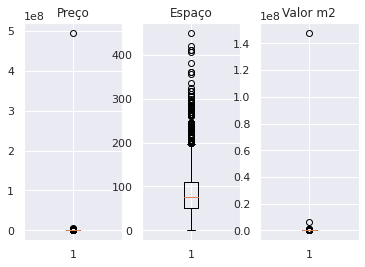

In [76]:
# Boxplot das variaveis continuas
fig, ax = plt.subplots(1, 3)

ax[0].boxplot(df['preco'])
ax[0].set_title('Preço')

ax[1].boxplot(df['espaco'])
ax[1].set_title('Espaço')

ax[2].boxplot(df['valor_m2'])
ax[2].set_title('Valor m2')

fig.show();

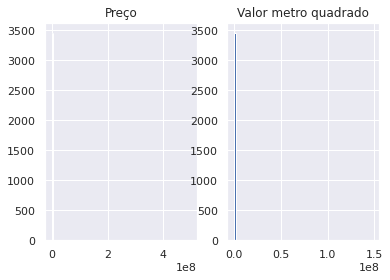

In [77]:
fig, ax = plt.subplots(1, 2)

ax[0].hist(df.preco, bins=100)
ax[0].set_title('Preço')

ax[1].hist(df.valor_m2, bins=100)
ax[1].set_title('Valor metro quadrado')

fig.show();

Os plots mostram que há outliers muito discrepantes, que devem ser retirados da base.

In [78]:
# Identificando valores inferiores a 50.000
index_50mil = df[df.preco < 50000].index
df.loc[index_50mil]

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
127,1145.0,9.0,3,2,2,122.0,-15.840670,-48.022060
270,1070.0,8.0,4,3,3,124.0,-15.836200,-48.033500
968,477.0,10.0,1,1,1,44.0,-15.836050,-48.019530
1008,1300.0,9.0,3,3,3,139.0,-15.840670,-48.022060
1080,0.0,0.0,1,1,1,57.0,-15.840670,-48.022060
1097,1.0,0.0,3,3,3,90.0,-15.840055,-48.022310
1323,0.0,0.0,4,3,3,203.0,-15.840670,-48.022060
1412,0.0,0.0,2,2,2,74.0,-15.840670,-48.022060
1428,1429.0,8.0,4,3,3,169.0,-15.840670,-48.022060
1702,1.0,0.0,2,1,1,54.0,-15.840670,-48.022060


In [79]:
# Excluindo os registros com valor inferior a 50mil
df.drop(index=index_50mil, inplace=True)

In [80]:
# Excluindo os valores extremos de preco e valor do metro quadrado
df.drop(index=df[df.preco == df.preco.max()].index, inplace=True)
df.drop(index=df[df.valor_m2 == df.valor_m2.max()].index, inplace=True)

In [81]:
# Descricao dos dados
df.describe()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
count,3.440000e+03,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000
mean,7.446150e+05,9247.220058,2.391279,1.499419,1.499419,88.336919,-15.839323,-48.025490
std,4.765507e+05,26371.234166,1.019344,1.018012,1.018012,52.544653,0.006025,0.008509
min,7.500000e+04,1730.000000,1.000000,0.000000,0.000000,1.000000,-15.877306,-48.047945
25%,4.300000e+05,7586.000000,2.000000,1.000000,1.000000,51.000000,-15.840670,-48.031983
50%,6.300000e+05,8530.500000,2.000000,2.000000,2.000000,75.000000,-15.839758,-48.022060
75%,8.900000e+05,9408.750000,3.000000,2.000000,2.000000,110.000000,-15.836632,-48.022060
max,5.496580e+06,970149.000000,5.000000,5.000000,5.000000,450.000000,-15.827535,-47.994065


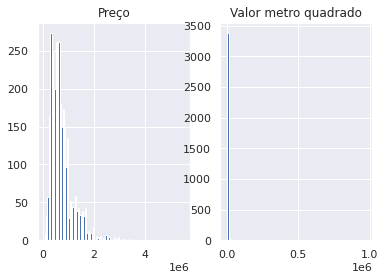

In [82]:
fig, ax = plt.subplots(1, 2)

ax[0].hist(df.preco, bins=100)
ax[0].set_title('Preço')

ax[1].hist(df.valor_m2, bins=100)
ax[1].set_title('Valor metro quadrado')

fig.show();

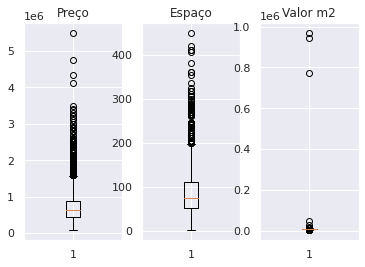

In [83]:
# Novo boxplot apos a retirada dos valores extremos
fig, ax = plt.subplots(1, 3)

ax[0].boxplot(df['preco'])
ax[0].set_title('Preço')

ax[1].boxplot(df['espaco'])
ax[1].set_title('Espaço')

ax[2].boxplot(df['valor_m2'])
ax[2].set_title('Valor m2')

fig.show();

In [84]:
# Excluindo pontos ainda muito discrepantes de metros quadrados
index_m2 = df.valor_m2.sort_values(ascending=False)[:4].index
df.drop(index=index_m2, inplace=True)

In [85]:
df.reset_index(inplace=True)
df.drop(columns='index', inplace=True)

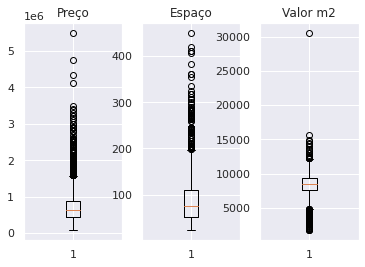

In [86]:
# Novo boxplot apos a retirada dos valores extremos
fig, ax = plt.subplots(1, 3)
# Boxplot de precos
ax[0].boxplot(df['preco'])
ax[0].set_title('Preço')
# Boxplot de espaco
ax[1].boxplot(df['espaco'])
ax[1].set_title('Espaço')
# Boxplot do valor do metro quadrado
ax[2].boxplot(df['valor_m2'])
ax[2].set_title('Valor m2')

fig.show();

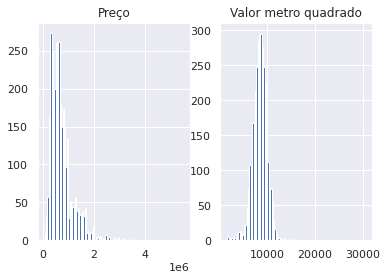

In [87]:
# Plot
fig, ax = plt.subplots(1, 2)
# Plot histograma precos
ax[0].hist(df.preco, bins=100)
ax[0].set_title('Preço')
# Plot histograma metro quadrado
ax[1].hist(df.valor_m2, bins=100)
ax[1].set_title('Valor metro quadrado')
# Mostrar a figura
fig.show();

In [88]:
df.describe()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
count,3.436000e+03,3436.000000,3436.000000,3436.000000,3436.000000,3436.000000,3436.000000,3436.000000
mean,7.438986e+05,8462.311991,2.390570,1.498545,1.498545,88.429278,-15.839313,-48.025489
std,4.763373e+05,1565.872014,1.018869,1.017030,1.017030,52.503274,0.006001,0.008513
min,7.500000e+04,1730.000000,1.000000,0.000000,0.000000,23.000000,-15.877306,-48.047945
25%,4.300000e+05,7586.000000,2.000000,1.000000,1.000000,52.000000,-15.840670,-48.031983
50%,6.300000e+05,8527.000000,2.000000,2.000000,2.000000,75.000000,-15.839758,-48.022060
75%,8.900000e+05,9408.000000,3.000000,2.000000,2.000000,110.000000,-15.836632,-48.022060
max,5.496580e+06,30555.000000,5.000000,5.000000,5.000000,450.000000,-15.827535,-47.994065


Os valores aparentam estar mais coerentes agora.

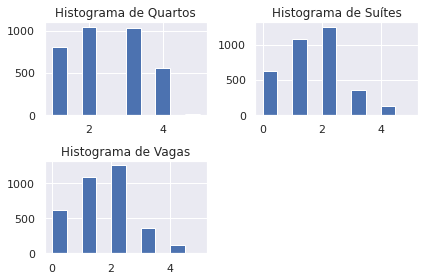

In [89]:
# Plot
fig, ax = plt.subplots(2, 2)
# Plot do histograma de quartos
ax[0, 0].hist(df['quartos'])
ax[0, 0].set_title('Histograma de Quartos')

# Plot do histograma de suítes
ax[0, 1].hist(df['suites'])
ax[0, 1].set_title('Histograma de Suítes')

# Plot do histograma de vagas
ax[1, 0].hist(df['vagas'])
ax[1, 0].set_title('Histograma de Vagas')

# Esconder o último subplot vazio
ax[1, 1].axis('off')

# Ajustar os espaçamentos entre os subplots
plt.tight_layout()

# Mostrar a figura
plt.show()

Podemos ver que quantidade de vagas e suites apresentam exatamente a mesma distribuição.

In [90]:
df.corr()

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
preco,1.000000,0.235463,0.720181,0.763402,0.763402,0.930450,0.081282,0.097521
valor_m2,0.235463,1.000000,-0.072993,0.035176,0.035176,-0.058156,0.229541,-0.113659
quartos,0.720181,-0.072993,1.000000,0.808265,0.808265,0.762642,0.046477,0.118835
suites,0.763402,0.035176,0.808265,1.000000,1.000000,0.770552,0.059154,0.117903
vagas,0.763402,0.035176,0.808265,1.000000,1.000000,0.770552,0.059154,0.117903
espaco,0.930450,-0.058156,0.762642,0.770552,0.770552,1.000000,0.032532,0.136176
latitude,0.081282,0.229541,0.046477,0.059154,0.059154,0.032532,1.000000,0.048602
longitude,0.097521,-0.113659,0.118835,0.117903,0.117903,0.136176,0.048602,1.000000


In [91]:
# Correlacao de Spearman eh mais apropriada para avaliar 
# a relacao entre dados discretos e continuos 
df.corr(method="spearman")

,preco,valor_m2,quartos,suites,vagas,espaco,latitude,longitude
preco,1.000000,0.130714,0.830695,0.817697,0.817697,0.945495,-0.000716,0.106887
valor_m2,0.130714,1.000000,-0.117166,-0.026302,-0.026302,-0.152867,0.002772,-0.131362
quartos,0.830695,-0.117166,1.000000,0.829482,0.829482,0.866977,-0.024944,0.117917
suites,0.817697,-0.026302,0.829482,1.000000,1.000000,0.831592,-0.037335,0.114552
vagas,0.817697,-0.026302,0.829482,1.000000,1.000000,0.831592,-0.037335,0.114552
espaco,0.945495,-0.152867,0.866977,0.831592,0.831592,1.000000,-0.013842,0.147679
latitude,-0.000716,0.002772,-0.024944,-0.037335,-0.037335,-0.013842,1.000000,0.081976
longitude,0.106887,-0.131362,0.117917,0.114552,0.114552,0.147679,0.081976,1.000000


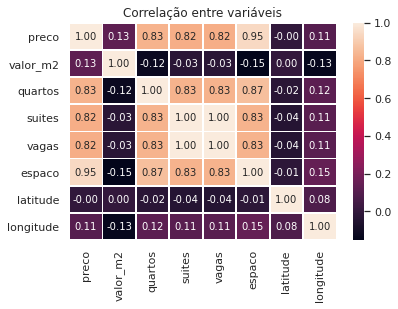

In [92]:
import seaborn as sns
plot = sns.heatmap(df.corr(method='spearman'), annot = True, fmt=".2f", linewidths=.6)
plot.set_title('Correlação entre variáveis')
sns.set(rc={'figure.figsize':(15,15)})
plot;

In [93]:
# Avaliando a relacao entre metro quadrado e preco do imovel
df2 = pd.DataFrame(columns=['preco', 'm2'])
df2['preco'], df2['m2'] = df.preco, df.valor_m2 * df.espaco

In [94]:
df2.describe()

,preco,m2
count,3.436000e+03,3.436000e+03
mean,7.438986e+05,7.435363e+05
std,4.763373e+05,4.763205e+05
min,7.500000e+04,7.497000e+04
25%,4.300000e+05,4.297042e+05
50%,6.300000e+05,6.299340e+05
75%,8.900000e+05,8.898922e+05
max,5.496580e+06,5.496428e+06


In [95]:
df2.corr()

,preco,m2
preco,1.000000,0.999996
m2,0.999996,1.000000


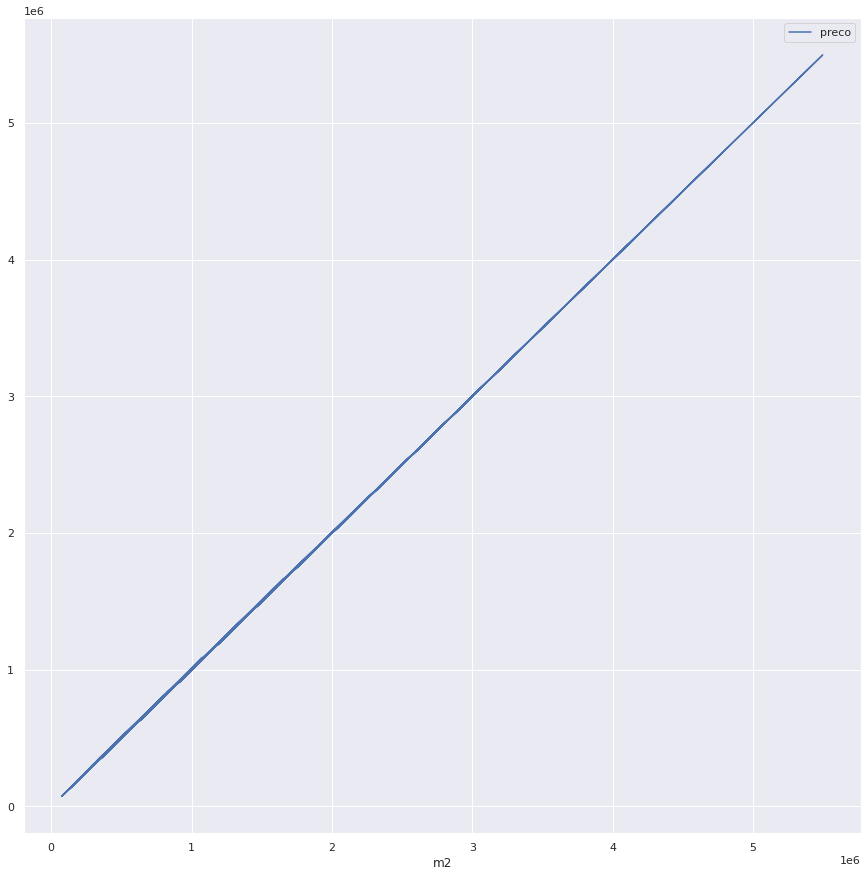

In [96]:
df2.plot(y='preco', x='m2');

In [97]:
# df.to_csv('/content/drive/MyDrive/Trabalhos/imoveis/imoveis_modelo2.csv',
#           sep=';',
#           encoding='utf-8',
#           index=False)

# Análise de Componentes Principais (PCA)

In [98]:
from sklearn.decomposition import PCA

In [152]:
def func_std(x):
    return (x - x.mean()) / x.std()

In [99]:
# Criando uma copia dos dados
df_pca = df[['quartos',
            'suites',
            'vagas',
            'espaco',
            'latitude',
            'longitude']]

In [122]:
# Padronizando os dados continuos
df_pca['espaco'] = func_std(df_pca['espaco'])
df_pca['latitude'] = func_std(df_pca['latitude'])
df_pca['longitude'] = func_std(df_pca['longitude'])

# y_train = (y_train - y_train.mean()) / y_train.std()

In [123]:
# Realizar a análise de PCA
pca = PCA()
pca.fit(df_pca)# Obter as proporções da variância explicada
explained_variance_ratio = pca.explained_variance_ratio_

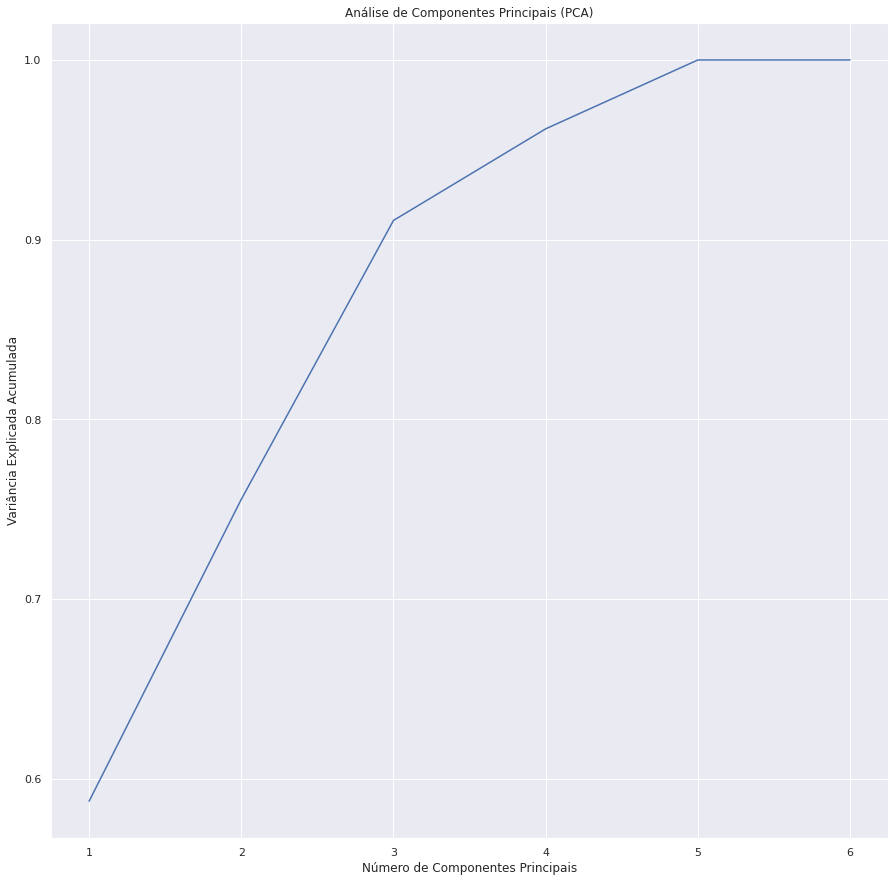

                PC1       PC2       PC3       PC4       PC5           PC6
quartos    0.486980  0.046834 -0.021917  0.291537 -0.821695  1.537454e-16
suites     0.517506  0.046732 -0.045225 -0.453369  0.149716  7.071068e-01
vagas      0.517506  0.046732 -0.045225 -0.453369  0.149716 -7.071068e-01
espaco     0.465152  0.041435  0.014905  0.708426  0.528987  1.247159e-16
latitude   0.040617 -0.787936 -0.613743  0.028196  0.005536 -8.946495e-17
longitude  0.095970 -0.608998  0.786464 -0.035440 -0.011386 -3.922237e-17


In [124]:
# Plotar a variância explicada acumulada
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio)
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Análise de Componentes Principais (PCA)')
plt.show();

# Obter os coeficientes do PCA (cargas)
loadings = pca.components_

# Mostrar os coeficientes e suas respectivas variáveis
loadings_df = pd.DataFrame(loadings.T, columns=['PC{}'.format(i+1) for i in range(len(loadings))], index=df_pca.columns)
print(loadings_df)

A analise por componentes principais mostra que com 4 variaveis temos mais de 95% da explicação do modelo e que a latitude e longitude, que nos testes de correlação se mostraram insignificantes, conjuntamente, estão entre as 3 variáveis mais importantes para previsão do modelo. Como as variáveis são altamente correlacionadas, devemos escolher com cuidado as mais importantes e não usar todas, para que não haja problemas como overfitting.

# Regressão linear multipla

## Regressão com statsmodels

In [134]:
import statsmodels.api as sm
import statsmodels
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

### Dividindo em treino e teste

In [136]:
df_stats = pd.get_dummies(df[['preco', 'suites', 'espaco', 'latitude', 'longitude']], columns=['suites']).drop(columns='suites_5')

In [139]:
df_stats.head()

,preco,espaco,latitude,longitude,suites_0,suites_1,suites_2,suites_3,suites_4
0,875000.0,93.0,-15.840670,-48.022060,0,0,1,0,0
1,650000.0,95.0,-15.840670,-48.022060,0,0,1,0,0
2,740000.0,101.0,-15.840670,-48.022060,0,0,1,0,0
3,1480000.0,180.0,-15.835735,-48.028668,0,0,1,0,0
4,1180000.0,131.0,-15.840610,-48.027707,0,0,0,1,0


In [150]:
X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(df_stats.iloc[:, 1:].values, 
                                                               df_stats.iloc[:, 0].values)

In [151]:
X_train_sm = pd.DataFrame(X_train_sm, columns=df_stats.columns[1:])


,espaco,latitude,longitude,suites_0,suites_1,suites_2,suites_3,suites_4
0,45.0,-15.830977,-48.011021,1.0,0.0,0.0,0.0,0.0
1,82.0,-15.836122,-48.040184,0.0,0.0,1.0,0.0,0.0
2,33.0,-15.875995,-47.994065,0.0,1.0,0.0,0.0,0.0
3,94.0,-15.840670,-48.022060,0.0,0.0,1.0,0.0,0.0
4,74.0,-15.840670,-48.022060,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2572,42.0,-15.840670,-48.022060,1.0,0.0,0.0,0.0,0.0
2573,119.0,-15.839115,-48.025925,0.0,0.0,1.0,0.0,0.0
2574,109.0,-15.840670,-48.022060,0.0,0.0,1.0,0.0,0.0
2575,136.0,-15.840670,-48.022060,0.0,0.0,0.0,1.0,0.0


In [129]:
# Padronizando os dados continuos
df_stats['espaco'] = func_std(df_stats['espaco'])
df_stats['latitude'] = func_std(df_stats['latitude'])
df_stats['longitude'] = func_std(df_stats['longitude'])
df_stats['preco'] = func_std(df_stats['preco'])

In [133]:
df_stats

,preco,espaco,latitude,longitude,suites_0,suites_1,suites_2,suites_3,suites_4
0,0.275228,0.087056,-0.226060,0.402844,0,0,1,0,0
1,-0.197126,0.125149,-0.226060,0.402844,0,0,1,0,0
2,-0.008185,0.239427,-0.226060,0.402844,0,0,1,0,0
3,1.545336,1.744095,0.596242,-0.373458,0,0,1,0,0
4,0.915531,0.810820,-0.216017,-0.260473,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
3431,-1.026370,-0.693848,-2.533525,-0.762887,1,0,0,0,0
3432,0.852550,0.944145,0.793790,-1.569514,0,0,1,0,0
3433,-0.365074,-0.636708,-0.226060,0.402844,0,1,0,0,0
3434,3.035877,2.810696,-0.226060,0.402844,0,0,0,1,0


In [148]:
X_train_sm = sm.add_constant(pd.DataFrame(X_train, columns=df.columns[1:]))
X_test_sm = sm.add_constant(pd.DataFrame(X_test, columns=df.columns[1:]))

ValueError: Shape of passed values is (2577, 8), indices imply (2577, 7)

In [76]:
model = sm.OLS(y_train, X_train_sm)

In [77]:
res = model.fit()

In [78]:
res

In [79]:
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     2465.
Date:                Wed, 27 Sep 2023   Prob (F-statistic):               0.00
Time:                        15:59:09   Log-Likelihood:                -872.32
No. Observations:                2577   AIC:                             1763.
Df Residuals:                    2568   BIC:                             1815.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3832      0.345      4.011      0.0

In [80]:
res.params

const        1.383233
espaco       0.784336
latitude     0.054471
longitude   -0.030688
suites_0    -1.518814
suites_1    -1.469389
suites_2    -1.419199
suites_3    -1.009104
suites_4    -0.629447
dtype: float64

In [81]:
# Obtenha as previsões para os dados de teste
y_pred = res.predict(sm.add_constant(pd.DataFrame(X_test, columns=df.columns[1:])))

In [91]:
y_pred.values

array([ 1.66728634e+00, -1.74487842e-01,  2.94616096e-01, -7.62073766e-01,
       -8.28636343e-03, -1.60312341e-04, -2.69254541e-01, -1.62495425e-01,
        3.60212944e-01,  1.13628902e-02,  1.56766489e+00,  4.01809375e-01,
       -8.21803181e-01,  1.69517673e+00, -1.99906003e-01, -5.24788742e-01,
       -2.26660514e-01,  3.21498122e-01, -6.48075123e-01,  1.49861640e+00,
       -5.95441965e-01,  3.84075819e-01, -6.48075123e-01, -9.36507322e-01,
        1.71366691e+00,  1.25863335e+00, -4.21005588e-01,  5.22129702e-01,
       -5.30155345e-01,  1.68593304e-01, -3.52003124e-01, -8.71847350e-01,
       -3.83314320e-01, -4.00686323e-01,  2.83820323e-01, -3.80535878e-01,
       -4.60958481e-01, -1.55311994e-01, -9.71285901e-01,  3.03668213e+00,
       -5.88155665e-01, -8.98654652e-01,  8.26860283e-02,  1.05489981e+00,
        3.31781022e+00, -1.40946114e-01, -8.44899963e-01, -3.47649351e-01,
       -4.21005588e-01,  3.35706775e-01,  1.87843009e+00,  2.11935812e-02,
       -9.85871053e-01,  

## Regressão Linear com SkLearn

## Pré-processamento dos dados

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [62]:
# Transformando suites em dummies
df = pd.get_dummies(df, columns=['suites'], prefix='suites')

# Como suites 5 contem apenas 1 registro, escolhi exclui-lo ao inves da primeira variavel
df.drop(columns='suites_5', inplace=True)

In [63]:
df_ = df.copy()

In [64]:
# Excluindo colunas desnecessarias
df.drop(columns=['quartos', 'vagas', 'valor_m2'], inplace=True)

In [66]:
# Separando a variavel dependente das variaveis explicativas
X = df.iloc[:, 1:].values

y = df.iloc[:, 0].values

In [65]:
df

,preco,espaco,latitude,longitude,suites_0,suites_1,suites_2,suites_3,suites_4
0,875000.0,93.0,-15.840670,-48.022060,0,0,1,0,0
1,650000.0,95.0,-15.840670,-48.022060,0,0,1,0,0
2,740000.0,101.0,-15.840670,-48.022060,0,0,1,0,0
3,1480000.0,180.0,-15.835735,-48.028668,0,0,1,0,0
4,1180000.0,131.0,-15.840610,-48.027707,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
3431,255000.0,52.0,-15.854517,-48.031983,1,0,0,0,0
3432,1150000.0,138.0,-15.834550,-48.038850,0,0,1,0,0
3433,570000.0,55.0,-15.840670,-48.022060,0,1,0,0,0
3434,2190000.0,236.0,-15.840670,-48.022060,0,0,0,1,0


In [67]:
# Separando o dataframe em dados de treino e dados de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [68]:
X_test[:,:3]


array([[179.        , -15.84134512, -48.01903285],
       [ 82.        , -15.83247087, -48.01034147],
       [109.        , -15.83975828, -48.03437399],
       ...,
       [ 92.        , -15.84067   , -48.02206   ],
       [109.        , -15.83182   , -48.034635  ],
       [ 45.        , -15.83106038, -48.01273094]])

In [69]:
# Padronizando os dados continuos
scaler = StandardScaler()
X_train[:,:3] = scaler.fit_transform(X_train[:,:3])
X_test[:,:3] = scaler.transform(X_test[:,:3])

y_train = scaler.fit_transform(y_train.reshape(-1, 1))
y_test = scaler.transform(y_test.reshape(-1, 1))

## Regressão Linear com SkLearn

In [75]:
from sklearn import linear_model

In [76]:
reg2 = linear_model.LinearRegression()
model2 = reg2.fit(X_train, y_train)

In [77]:
# Coeficientes do modelo
print('Valor de alpha:', reg2.intercept_[0])
print('Valores dos betas:', reg2.coef_[0])

Valor de alpha: 1.383233266273904
Valores dos betas: [ 0.78433599  0.0544708  -0.03068776 -1.51881442 -1.4693893  -1.41919943
 -1.00910369 -0.6294467 ]


In [78]:
kfold = KFold(n_splits=15, shuffle=True, random_state=5)

In [79]:
resultado2 = cross_val_score(model2, X_test, y_test, cv=kfold)

In [80]:
print('Acurácia Média: %.2f%%' % (resultado2.mean() * 100.0))

Acurácia Média: 88.45%


# Cluster de valor x localização

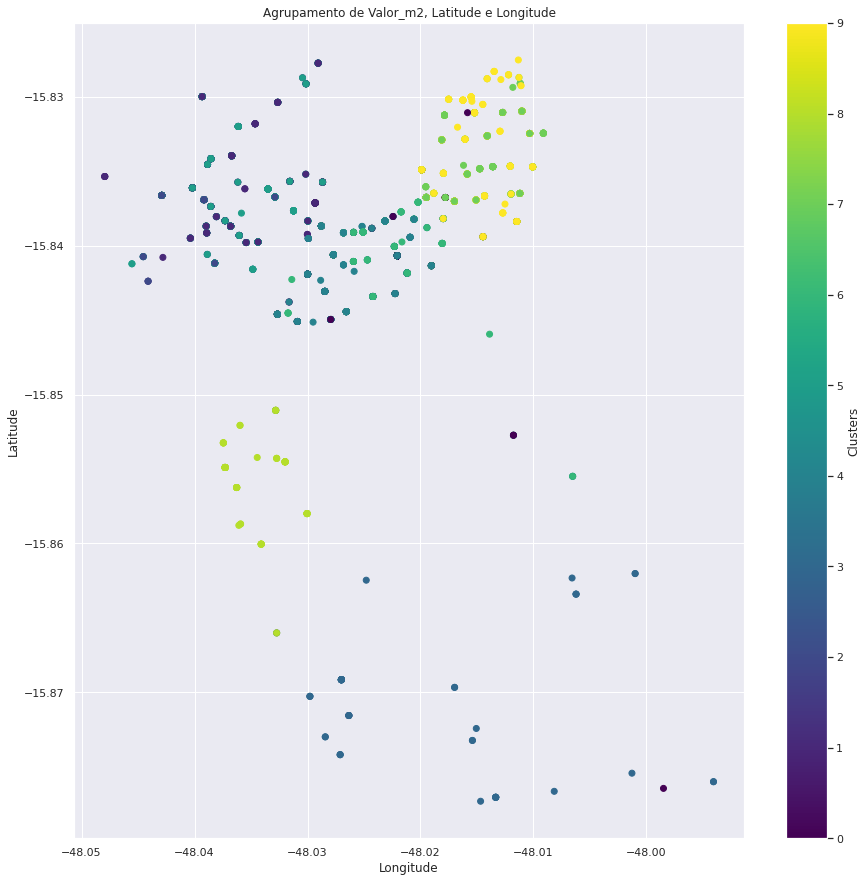

In [81]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Selecionar as variáveis relevantes
variables = df_[['valor_m2', 'latitude', 'longitude']]

# Normalizar as variáveis
normalized_df = (variables - variables.mean()) / variables.std()

# Definir o número de clusters
num_clusters = 10

# Executar o algoritmo de agrupamento (K-means)
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(normalized_df)

# Obter os rótulos de cluster para cada amostra
cluster_labels = kmeans.labels_

# Adicionar os rótulos de cluster ao DataFrame original
df['cluster'] = cluster_labels

# Visualizar os resultados
plt.scatter(df['longitude'], df['latitude'], c=df['cluster'], cmap='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Agrupamento de Valor_m2, Latitude e Longitude')

# Adicionar legenda para as cores dos clusters
cbar = plt.colorbar()
cbar.set_label('Clusters')

plt.show();

<Figure size 720x720 with 0 Axes>

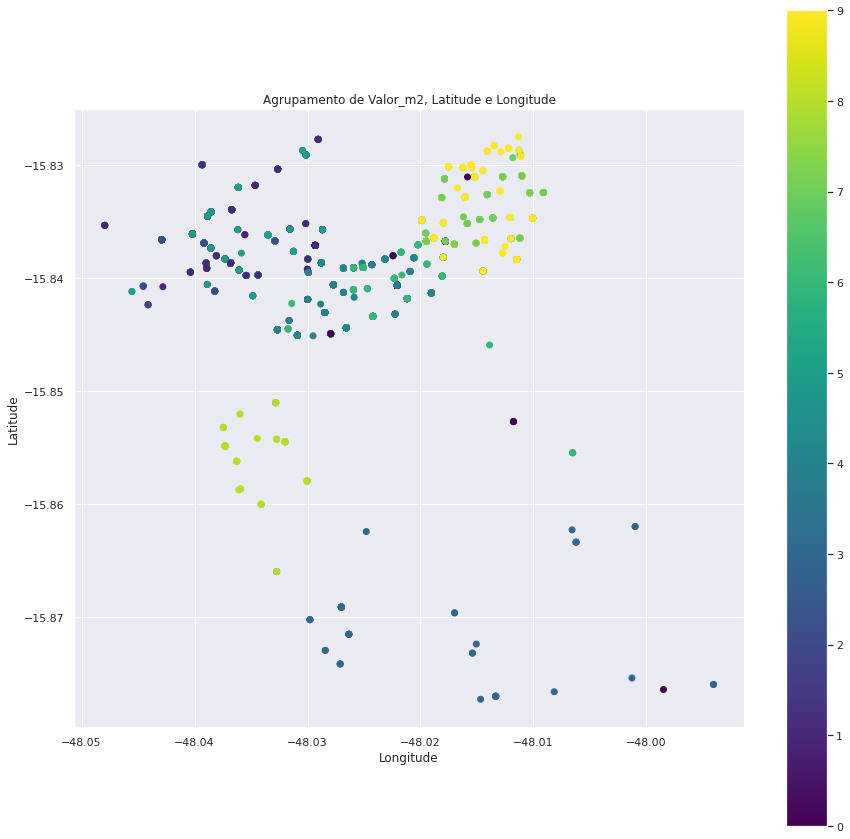

In [84]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import geopandas as gpd

# Selecionar as variáveis relevantes
variables = df_[['valor_m2', 'latitude', 'longitude']]

# Normalizar as variáveis
normalized_df = (variables - variables.mean()) / variables.std()

# Definir o número de clusters
num_clusters = 10

# Executar o algoritmo de agrupamento (K-means)
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(normalized_df)

# Obter os rótulos de cluster para cada amostra
cluster_labels = kmeans.labels_

# Adicionar os rótulos de cluster ao DataFrame original
df['cluster'] = cluster_labels

# Converta o DataFrame para um GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

# Plotar o mapa
plt.figure(figsize=(10, 10))
ax = gdf.plot(column='cluster', cmap='viridis', legend=True)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Agrupamento de Valor_m2, Latitude e Longitude')

plt.show();